# PaceMap AI
Full pipeline: parse GPX → calculate paces → chart → interactive map → ML finish time prediction.

> **Click ▶▶ Run All — no changes needed.**

## 0. Local System Setup

setting up directory, the paths relative to notebook

In [16]:
import sys, os

# Resolve paths relative to this notebook — works regardless of kernel cwd
NOTEBOOK_DIR = os.path.dirname(os.path.abspath(
    globals().get('__vsc_ipynb_file__') or os.path.join(os.getcwd(), 'create_notebook.ipynb')
))
SRC_DIR = os.path.join(NOTEBOOK_DIR, 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

GPX_FILE_PATH    = os.path.join(NOTEBOOK_DIR, 'data', 'raw_gpx', 'run_44.gpx')
OUTPUT_MAP       = os.path.join(NOTEBOOK_DIR, 'output', 'pace_map.html')
SMOOTHING_WINDOW = 3
MAP_ZOOM         = 14

os.makedirs(os.path.dirname(OUTPUT_MAP), exist_ok=True)
print(f'Notebook dir : {NOTEBOOK_DIR}')
print(f'src on path  : {SRC_DIR}')
print(f'GPX file     : {GPX_FILE_PATH}')
print(f'Map output   : {OUTPUT_MAP}')

Notebook dir : /Users/zhenweiyap/Documents/Github/PaceMap-AI
src on path  : /Users/zhenweiyap/Documents/Github/PaceMap-AI/src
GPX file     : /Users/zhenweiyap/Documents/Github/PaceMap-AI/data/raw_gpx/run_44.gpx
Map output   : /Users/zhenweiyap/Documents/Github/PaceMap-AI/output/pace_map.html


## 1. Parse GPX  _(parser.py)_

is responsible for reading and extracting data from GPX files (GPS exchange format - the standard format for GPS tracking data).

convert a gpx file into python data structures that can be analysed.

In [17]:
from parser import load_gpx_file, extract_track_points, extract_coordinates, extract_timestamps, extract_elevations

gpx          = load_gpx_file(GPX_FILE_PATH)
track_points = extract_track_points(gpx)
coordinates  = extract_coordinates(track_points)
timestamps   = extract_timestamps(track_points)
elevations   = extract_elevations(track_points)

print(f"Track points : {len(track_points)}")
print(f"Start        : {timestamps[0]}")
print(f"End          : {timestamps[-1]}")
print(f"First coord  : {coordinates[0]}")
print(f"Last  coord  : {coordinates[-1]}")

Track points : 2667
Start        : 2025-02-02 09:41:08+00:00
End          : 2025-02-02 10:25:55+00:00
First coord  : (51.511247, -0.318012)
Last  coord  : (51.510739, -0.310737)


## 2. Calculate Paces and Distances  _(pace_calculator.py + utils.py)_

In [18]:
from pace_calculator import smooth_gps_coordinates, calculate_segment_distances, calculate_cumulative_distance, calculate_segment_paces
from utils import format_pace, format_distance, format_duration, elevation_gain, elapsed_seconds, metres_to_km, deduplicate_timestamps

timestamps_clean  = deduplicate_timestamps(timestamps)
smooth_coords     = smooth_gps_coordinates(coordinates, window=SMOOTHING_WINDOW)
segment_distances = calculate_segment_distances(smooth_coords)
cumulative        = calculate_cumulative_distance(segment_distances)
total_distance_m  = cumulative[-1]
segment_paces     = calculate_segment_paces(smooth_coords, timestamps_clean)

valid_paces   = [p for p in segment_paces if p > 0]
avg_pace      = sum(valid_paces) / len(valid_paces) if valid_paces else 0
total_elapsed = elapsed_seconds(timestamps[0], timestamps[-1])
elev_gain     = elevation_gain(elevations)

print(f"Total distance : {format_distance(total_distance_m)}")
print(f"Total time     : {format_duration(total_elapsed or 0)}")
print(f"Average pace   : {format_pace(avg_pace)}")
print(f"Elevation gain : {elev_gain:.1f} m")
print(f"Segments       : {len(segment_paces)}")

Total distance : 7.92 km
Total time     : 0:44:47
Average pace   : 6:08 /km
Elevation gain : 25.1 m
Segments       : 2666


## 3. Pace Distribution Chart  _(utils.py)_

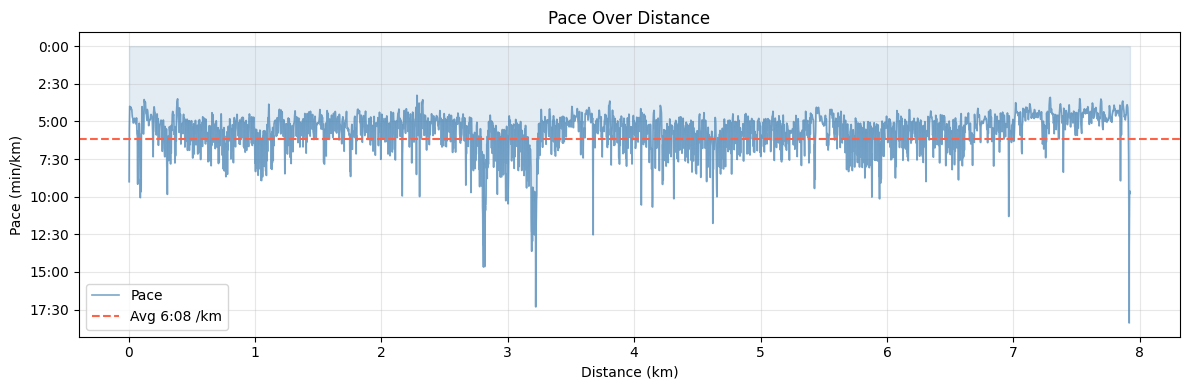

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

cum_km    = [d / 1000 for d in cumulative[:-1]]
pace_mins = [p / 60 for p in segment_paces]
filtered  = [(k, p) for k, p in zip(cum_km, pace_mins) if 0 < p < 20]
x_vals, y_vals = zip(*filtered) if filtered else ([], [])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x_vals, y_vals, linewidth=1.2, color='steelblue', alpha=0.7, label='Pace')
ax.fill_between(x_vals, y_vals, alpha=0.15, color='steelblue')
ax.axhline(avg_pace / 60, color='tomato', linestyle='--', linewidth=1.5, label=f'Avg {format_pace(avg_pace)}')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v)}:{int((v % 1)*60):02d}"))
ax.invert_yaxis()
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Pace (min/km)')
ax.set_title('Pace Over Distance')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Build & Export Pace Map  _(map_visualizer.py)_

In [20]:
from map_visualizer import build_activity_map, export_map_html

activity_map = build_activity_map(
    coordinates=smooth_coords,
    paces=segment_paces,
    activity_name='Run',
    zoom_start=MAP_ZOOM,
)
export_map_html(activity_map, OUTPUT_MAP)
print(f"Map saved to: {OUTPUT_MAP}")
activity_map

Map saved to: /Users/zhenweiyap/Documents/Github/PaceMap-AI/output/pace_map.html


## 5. ML Finish Time Prediction
Trains Linear Regression, Random Forest and Gradient Boosting, picks the best R² model, then predicts this run's finish time.

In [21]:
import numpy as np
import pandas as pd
from ml_model import train_model, evaluate_model, predict, TARGET_COLUMN, SUPPORTED_MODELS

rng = np.random.default_rng(42)
n   = 300
sample_data = pd.DataFrame({
    'distance_km'       : rng.uniform(5, 42, n),
    'elevation_gain_m'  : rng.uniform(0, 500, n),
    'avg_pace_s_per_km' : rng.uniform(240, 420, n),
    'avg_heart_rate_bpm': rng.uniform(130, 180, n),
    'temperature_c'     : rng.uniform(5, 30, n),
    'time_of_day_hour'  : rng.uniform(5, 20, n),
    'fatigue_score'     : rng.uniform(0, 10, n),
})
sample_data[TARGET_COLUMN] = (
    sample_data['distance_km'] * sample_data['avg_pace_s_per_km']
    + rng.normal(0, 60, n)
)

results = {}
for model_type in SUPPORTED_MODELS:
    pipeline, _, _, X_test, y_test = train_model(sample_data, model_type=model_type)
    metrics = evaluate_model(pipeline, X_test, y_test)
    results[model_type] = {'pipeline': pipeline, 'metrics': metrics}
    print(f"{model_type:<20} MAE={metrics['mae']:.0f}s  RMSE={metrics['rmse']:.0f}s  R2={metrics['r2']:.4f}")

best_type     = max(results, key=lambda m: results[m]['metrics']['r2'])
best_pipeline = results[best_type]['pipeline']
print(f"\nBest model: {best_type}")

linear               MAE=376s  RMSE=476s  R2=0.9851
random_forest        MAE=410s  RMSE=501s  R2=0.9834
gradient_boosting    MAE=226s  RMSE=297s  R2=0.9942

Best model: gradient_boosting


In [ ]:
run_features = {
    'distance_km'       : metres_to_km(total_distance_m),
    'elevation_gain_m'  : elev_gain,
    'avg_pace_s_per_km' : avg_pace,
    'avg_heart_rate_bpm': 155.0,
    'temperature_c'     : 15.0,
    'time_of_day_hour'  : timestamps[0].hour if timestamps[0] else 8,
    'fatigue_score'     : 5.0,
}

predicted_s = predict(best_pipeline, run_features)
actual_s    = total_elapsed or 0

print(f"Predicted finish time : {format_duration(predicted_s)}")
print(f"Actual finish time    : {format_duration(actual_s)}")
print(f"Difference            : {format_duration(abs(predicted_s - actual_s))}")

Predicted finish time : 0:46:34
Actual finish time    : 0:44:47
Difference            : 0:01:47
